In [24]:
import math as m
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
import CoolProp.CoolProp as cp

In [13]:
#load data

time_raw = np.char.strip(time_strings, '"')
time_only = np.char.partition(time_raw, " ")[..., 2]

time_dt = np.array(
    [dt.datetime.strptime(s, "%m/%d/%y %H:%M:%S") for s in time_raw]
)
time = np.array(
    [(t - time_dt[0]).total_seconds() for t in time_dt],
    dtype=int
)

chA, chB = np.loadtxt(
    "data/datalmao.txt",
    delimiter=",",
    skiprows=1,
    usecols=(1, 2),
    unpack=True
)
## PTA is the outlet of the valve, PTB is the inlet.
ptA = 250 * chA - 125
ptB = 250 * chB - 125
mask = time <= 1500
ptAT = ptA - ptA[mask].mean()
ptBT = ptB - ptB[mask].mean()


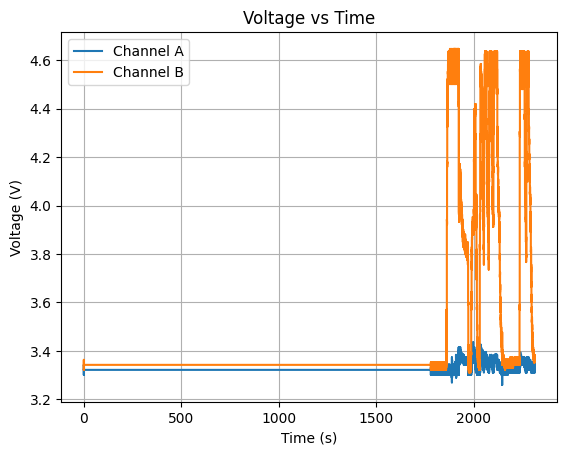

In [10]:
# raw voltage
plt.plot(time, chA, label="Channel A")
plt.plot(time, chB, label="Channel B")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title("Voltage vs Time")
plt.legend()
plt.grid()
plt.show()


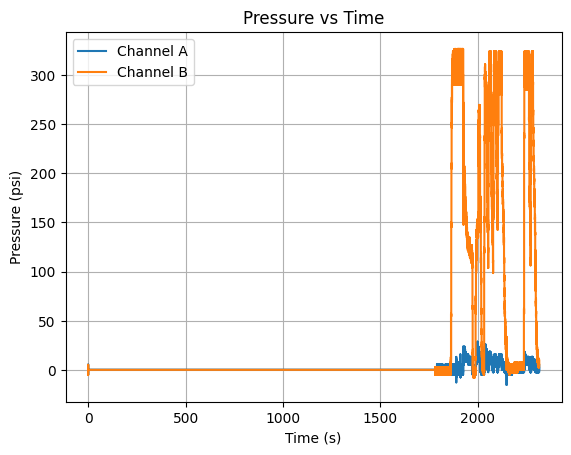

In [14]:
#raw pressure
plt.plot(time, ptAT, label="Channel A")
plt.plot(time, ptBT, label="Channel B")
plt.xlabel("Time (s)")
plt.ylabel("Pressure (psi)")
plt.title("Pressure vs Time")
plt.legend()
plt.grid()
plt.show()


Estimated sampling rate: 1441.32 Hz
Top noise frequencies for Channel A:
  0.000 Hz, amplitude 2.079e+04
  0.001 Hz, amplitude 1.769e+04
  0.001 Hz, amplitude 1.764e+04
  0.004 Hz, amplitude 1.310e+04
  0.006 Hz, amplitude 1.210e+04
Top noise frequencies for Channel B:
  0.001 Hz, amplitude 9.160e+05
  0.000 Hz, amplitude 3.486e+05
  0.006 Hz, amplitude 2.848e+05
  0.002 Hz, amplitude 2.664e+05
  0.003 Hz, amplitude 2.139e+05


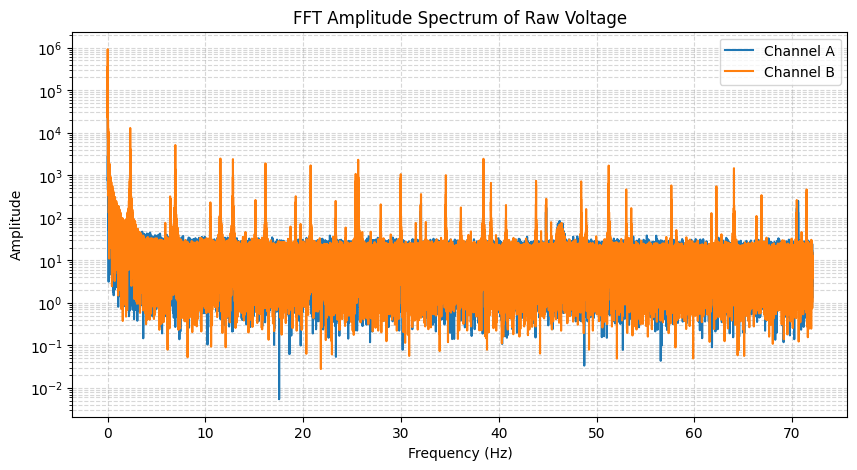

In [23]:
# FFT of raw voltage data to find strongest noise frequencies
N = len(chA)
duration = time[-1] - time[0]
fs = N / duration if duration > 0 else 1.0
signalA = chA - np.mean(chA)
signalB = chB - np.mean(chB)
fftA = np.fft.rfft(signalA)
fftB = np.fft.rfft(signalB)
freqs = np.fft.rfftfreq(N, d=1 / fs)
ampA = np.abs(fftA)
ampB = np.abs(fftB)
topA = np.argsort(ampA[1:])[::-1][:5] + 1
topB = np.argsort(ampB[1:])[::-1][:5] + 1
print(f"Estimated sampling rate: {fs:.2f} Hz")
print("Top noise frequencies for Channel A:")
for idx in topA:
    print(f"  {freqs[idx]:.3f} Hz, amplitude {ampA[idx]:.3e}")
print("Top noise frequencies for Channel B:")
for idx in topB:
    print(f"  {freqs[idx]:.3f} Hz, amplitude {ampB[idx]:.3e}")
plt.figure(figsize=(10, 5))
max_plot_freq = int(len(freqs) * 0.1)
plt.semilogy(freqs[1:max_plot_freq], ampA[1:max_plot_freq], label="Channel A")
plt.semilogy(freqs[1:max_plot_freq], ampB[1:max_plot_freq], label="Channel B")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("FFT Amplitude Spectrum of Raw Voltage")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

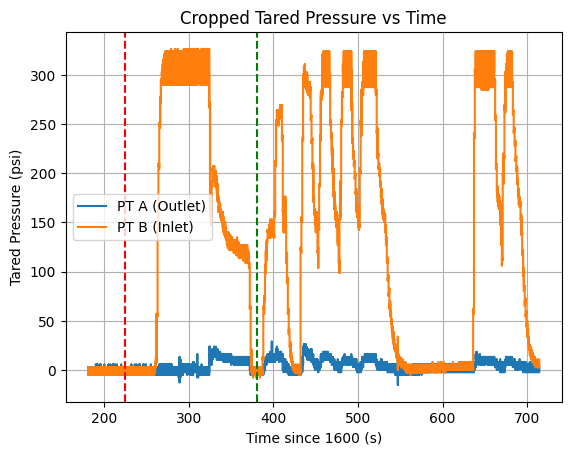

In [29]:
post1600 = time > 1600

timeCrop = time[post1600] - 1600
chACrop = chA[post1600]
chBCrop = chB[post1600]
ptACrop = ptA[post1600]
ptBCrop = ptB[post1600]
ptATCrop = ptAT[post1600]
ptBTCrop = ptBT[post1600]
timeDtCrop = time_dt[post1600]
timeOnlyCrop = time_only[post1600]
timeRawCrop = time_raw[post1600]
timeStringsCrop = time_strings[post1600]

plt.plot(timeCrop, ptATCrop, label="PT A (Outlet)")
plt.plot(timeCrop, ptBTCrop, label="PT B (Inlet)")
plt.xlabel("Time since 1600 (s)")
plt.ylabel("Tared Pressure (psi)")
plt.title("Cropped Tared Pressure vs Time")
plt.legend()
plt.grid()
plt.axvline(x=225, color="red", linestyle="--", label="Steady State")
plt.axvline(x=380, color="green", linestyle="--", label="Valve Close")
plt.show()

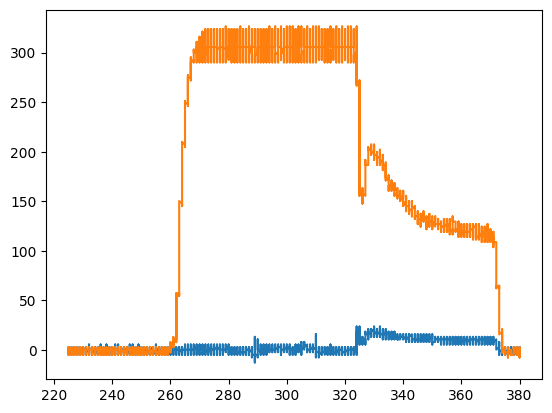

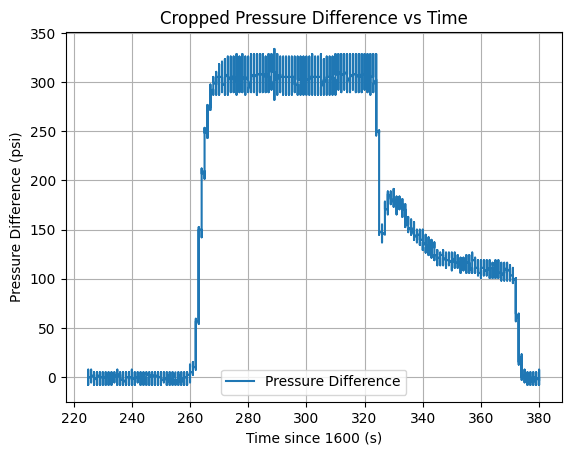

Mean CdA for mdot=1.0 kg/s: 1.327306e-04 m^2
Median CdA for mdot=1.0 kg/s: 2.584801e-05 m^2


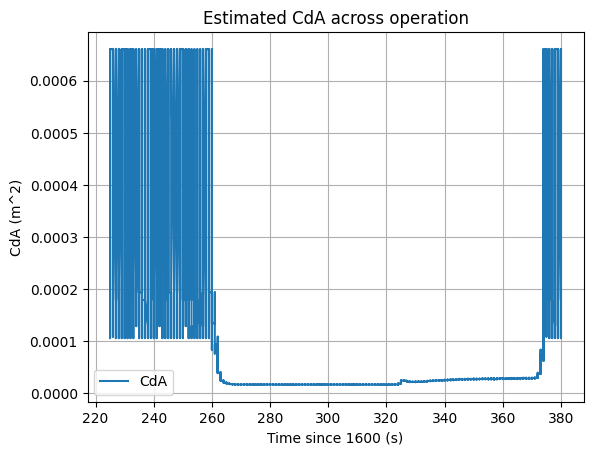

In [39]:
post225380 = (timeCrop >= 225) & (timeCrop <= 380)

timeCrop2 = timeCrop[post225380]
ptATCrop2 = ptATCrop[post225380]
ptBTCrop2 = ptBTCrop[post225380]
plt.plot(timeCrop2, ptATCrop2, label="PT A (Outlet)")
plt.plot(timeCrop2, ptBTCrop2, label="PT B (Inlet)")

# find CdA
dP = ptBTCrop2 - ptATCrop2
plt.figure()
plt.plot(timeCrop2, dP, label="Pressure Difference")
plt.xlabel("Time since 1600 (s)")
plt.ylabel("Pressure Difference (psi)")
plt.title("Cropped Pressure Difference vs Time")
plt.legend()
plt.grid()
plt.show()

rhoLn2 = cp.PropsSI("D", "T", 77.0, "Q", 0, "N2")
dPPa = dP * 6894.757293168
dPPaMag = np.abs(dPPa)
valid = dPPaMag > 0.0

mdot = 1.0  # kg/s, replace with actual mass flow if known
CdA = np.full_like(dPPaMag, np.nan, dtype=float)
CdA[valid] = mdot / np.sqrt(2.0 * rhoLn2 * dPPaMag[valid])

print(f"Mean CdA for mdot={mdot} kg/s: {np.nanmean(CdA):.6e} m^2")
print(f"Median CdA for mdot={mdot} kg/s: {np.nanmedian(CdA):.6e} m^2")

plt.plot(timeCrop2, CdA, label="CdA")
plt.xlabel("Time since 1600 (s)")
plt.ylabel("CdA (m^2)")
plt.title("Estimated CdA across operation")
plt.legend()
plt.grid()
plt.show()
